# Data & Feature Visualization

This notebook provides an end-to-end visual tour of the SVD dataset and the extracted features.

**Sections:**
1. Dataset Overview — class balance, speaker demographics, modalities
2. Raw Audio — waveform and Log-Mel Spectrogram per pathology
3. Acoustic Features (Librosa) — F0, RMS, MFCC, spectral features
4. Multifractal Features (MFDFA) — h(q), τ(q), singularity spectrum
5. OpenSMILE Features (eGeMAPSv02) — feature distributions and correlations
6. Feature Space — PCA and t-SNE projections coloured by pathology

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sys.path.append('..')
from src.features import FeatureOptions, load_feature_tables

sns.set_theme(style='whitegrid', palette='tab10')
RANDOM_SEED = 42
PREFIX = Path('..')

g:\Projects\multifractal-speech-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
opts = FeatureOptions(
    prefix=PREFIX,
    include_splits=True,
    random_seed=RANDOM_SEED,
    max_samples_per_class=200,
)

tables = load_feature_tables(options=opts, build_if_missing=True, save_if_built=True)

core_df        = tables['core'].copy()
acoustic_df    = tables['acoustic'].copy()
multifractal_df = tables['multifractal'].copy()
opensmile_df   = tables.get('opensmile', pd.DataFrame()).copy()

# Build full joined table
df = core_df.merge(acoustic_df, on='sample_key', how='left')
df = df.merge(multifractal_df, on='sample_key', how='left')
if not opensmile_df.empty:
    df = df.merge(opensmile_df, on='sample_key', how='left')

# Keep only successfully extracted samples
for status_col, ok_val in [('feature_status', ['ok', 'partial_failure']),
                             ('acoustic_status', ['ok']),
                             ('mf_status', ['ok'])]:
    if status_col in df.columns:
        df = df[df[status_col].isin(ok_val)]

df = df.reset_index(drop=True)
print(f'Samples available: {len(df)}')
df['pathology_de'].value_counts()

Samples available: 1214


pathology_de
Phonationsknötchen       200
Reinke Ödem              200
Rekurrensparese           200
Spasmodische Dysphonie    200
Stimmlippenpolyp          200
healthy                   200
Morbus Parkinson           14
Name: count, dtype: int64

---
## 1  Dataset Overview

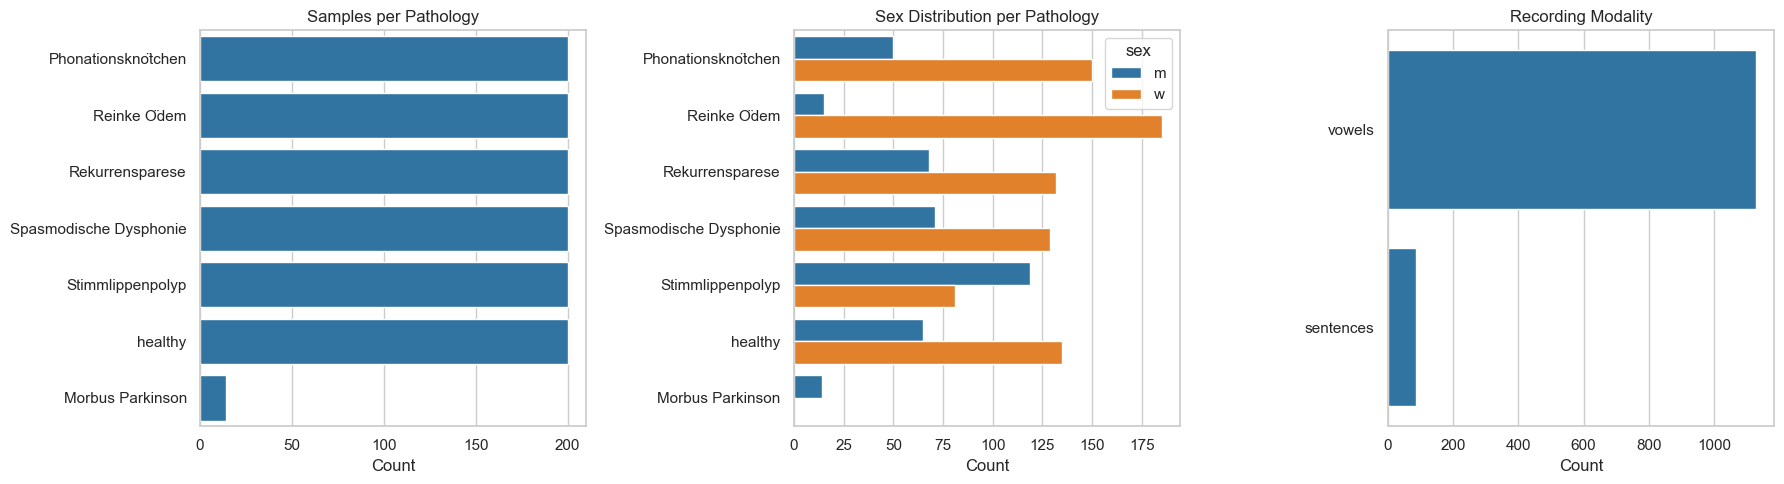

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a — class balance
order = df['pathology_de'].value_counts().index
sns.countplot(data=df, y='pathology_de', order=order, ax=axes[0])
axes[0].set_title('Samples per Pathology')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

# 1b — sex distribution per pathology
sex_counts = df.groupby(['pathology_de', 'sex']).size().reset_index(name='n')
sns.barplot(data=sex_counts, y='pathology_de', x='n', hue='sex',
            order=order, ax=axes[1])
axes[1].set_title('Sex Distribution per Pathology')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

# 1c — modality distribution
if 'modality' in df.columns:
    modality_order = df['modality'].value_counts().index
    sns.countplot(data=df, y='modality', order=modality_order, ax=axes[2])
    axes[2].set_title('Recording Modality')
    axes[2].set_xlabel('Count')
    axes[2].set_ylabel('')
else:
    axes[2].axis('off')

plt.tight_layout()
plt.show()

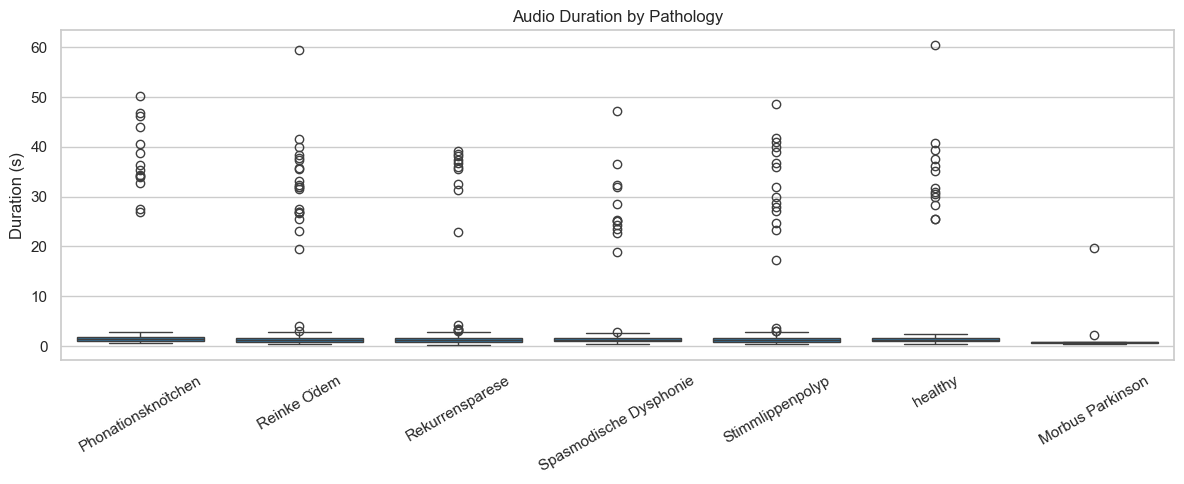

In [4]:
if 'audio_duration_seconds' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df, x='pathology_de', y='audio_duration_seconds',
                order=order, ax=ax)
    ax.set_title('Audio Duration by Pathology')
    ax.set_xlabel('')
    ax.set_ylabel('Duration (s)')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

---
## 2  Raw Audio — Waveform & Log-Mel Spectrogram

One representative vowel `/a/` recording per pathology class.

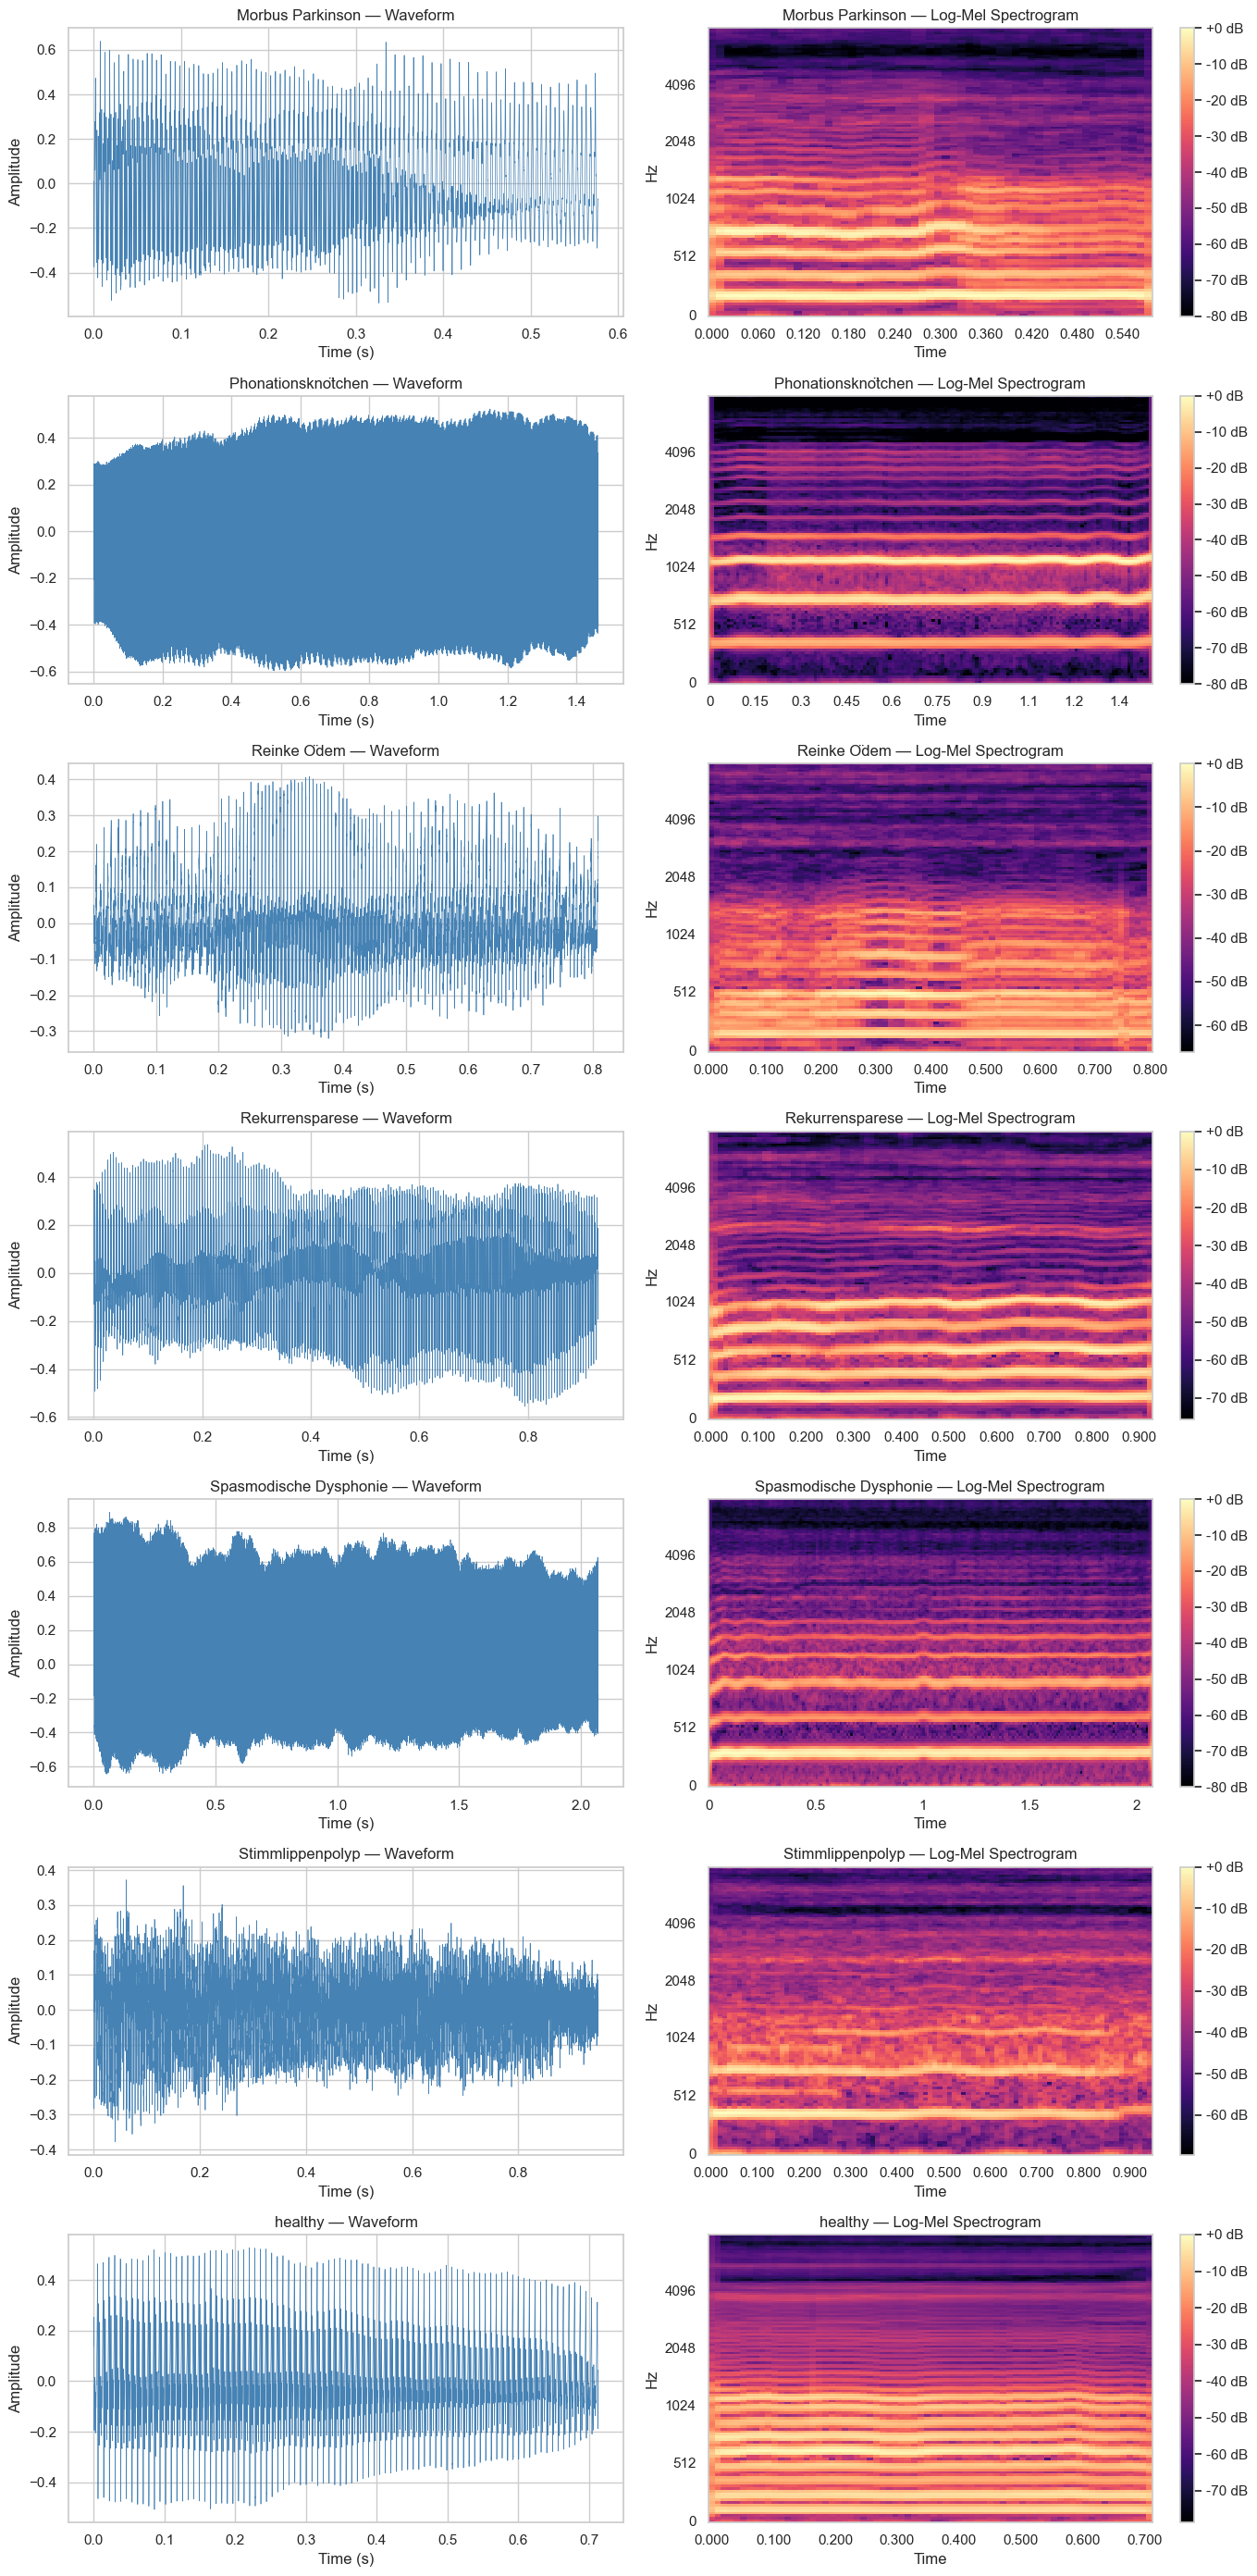

In [5]:
def resolve_wav(wav_path_raw: str) -> Path:
    p = Path(wav_path_raw)
    if p.is_absolute() and p.exists():
        return p
    # try relative to notebook directory
    nb_rel = Path('.') / p
    if nb_rel.exists():
        return nb_rel
    # try relative to project root
    proj_rel = PREFIX / p
    if proj_rel.exists():
        return proj_rel
    # strip leading '..'
    parts = list(p.parts)
    while parts and parts[0] in ('..', '.'):
        parts = parts[1:]
    fallback = PREFIX / Path(*parts)
    return fallback


# Pick one 'a_h' vowel sample per class
token_pref = 'a_h' if 'token' in df.columns else None
groups = df['pathology_de'].unique()

samples = []
for cls in sorted(groups):
    sub = df[df['pathology_de'] == cls]
    if token_pref:
        vow = sub[sub['token'] == token_pref]
        sub = vow if not vow.empty else sub
    samples.append(sub.iloc[0])

N = len(samples)
fig, axes = plt.subplots(N, 2, figsize=(14, 4 * N))

for row_idx, row in enumerate(samples):
    wav_path = resolve_wav(str(row['wav_path']))
    label = row['pathology_de']

    try:
        y, sr = librosa.load(str(wav_path), sr=None, mono=True)

        # Waveform
        ax_w = axes[row_idx, 0]
        times = np.linspace(0, len(y) / sr, num=len(y))
        ax_w.plot(times, y, linewidth=0.5, color='steelblue')
        ax_w.set_title(f'{label} — Waveform')
        ax_w.set_xlabel('Time (s)')
        ax_w.set_ylabel('Amplitude')

        # Log-Mel Spectrogram
        ax_s = axes[row_idx, 1]
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        img = librosa.display.specshow(
            mel_db, sr=sr, x_axis='time', y_axis='mel',
            fmax=8000, ax=ax_s, cmap='magma'
        )
        fig.colorbar(img, ax=ax_s, format='%+2.0f dB')
        ax_s.set_title(f'{label} — Log-Mel Spectrogram')

    except Exception as e:
        axes[row_idx, 0].set_title(f'{label} — load error: {e}')
        axes[row_idx, 1].axis('off')

plt.tight_layout()
plt.show()

---
## 3  Acoustic Features (Librosa)

Feature distributions across pathology classes: fundamental frequency, RMS energy, spectral features, and MFCCs.

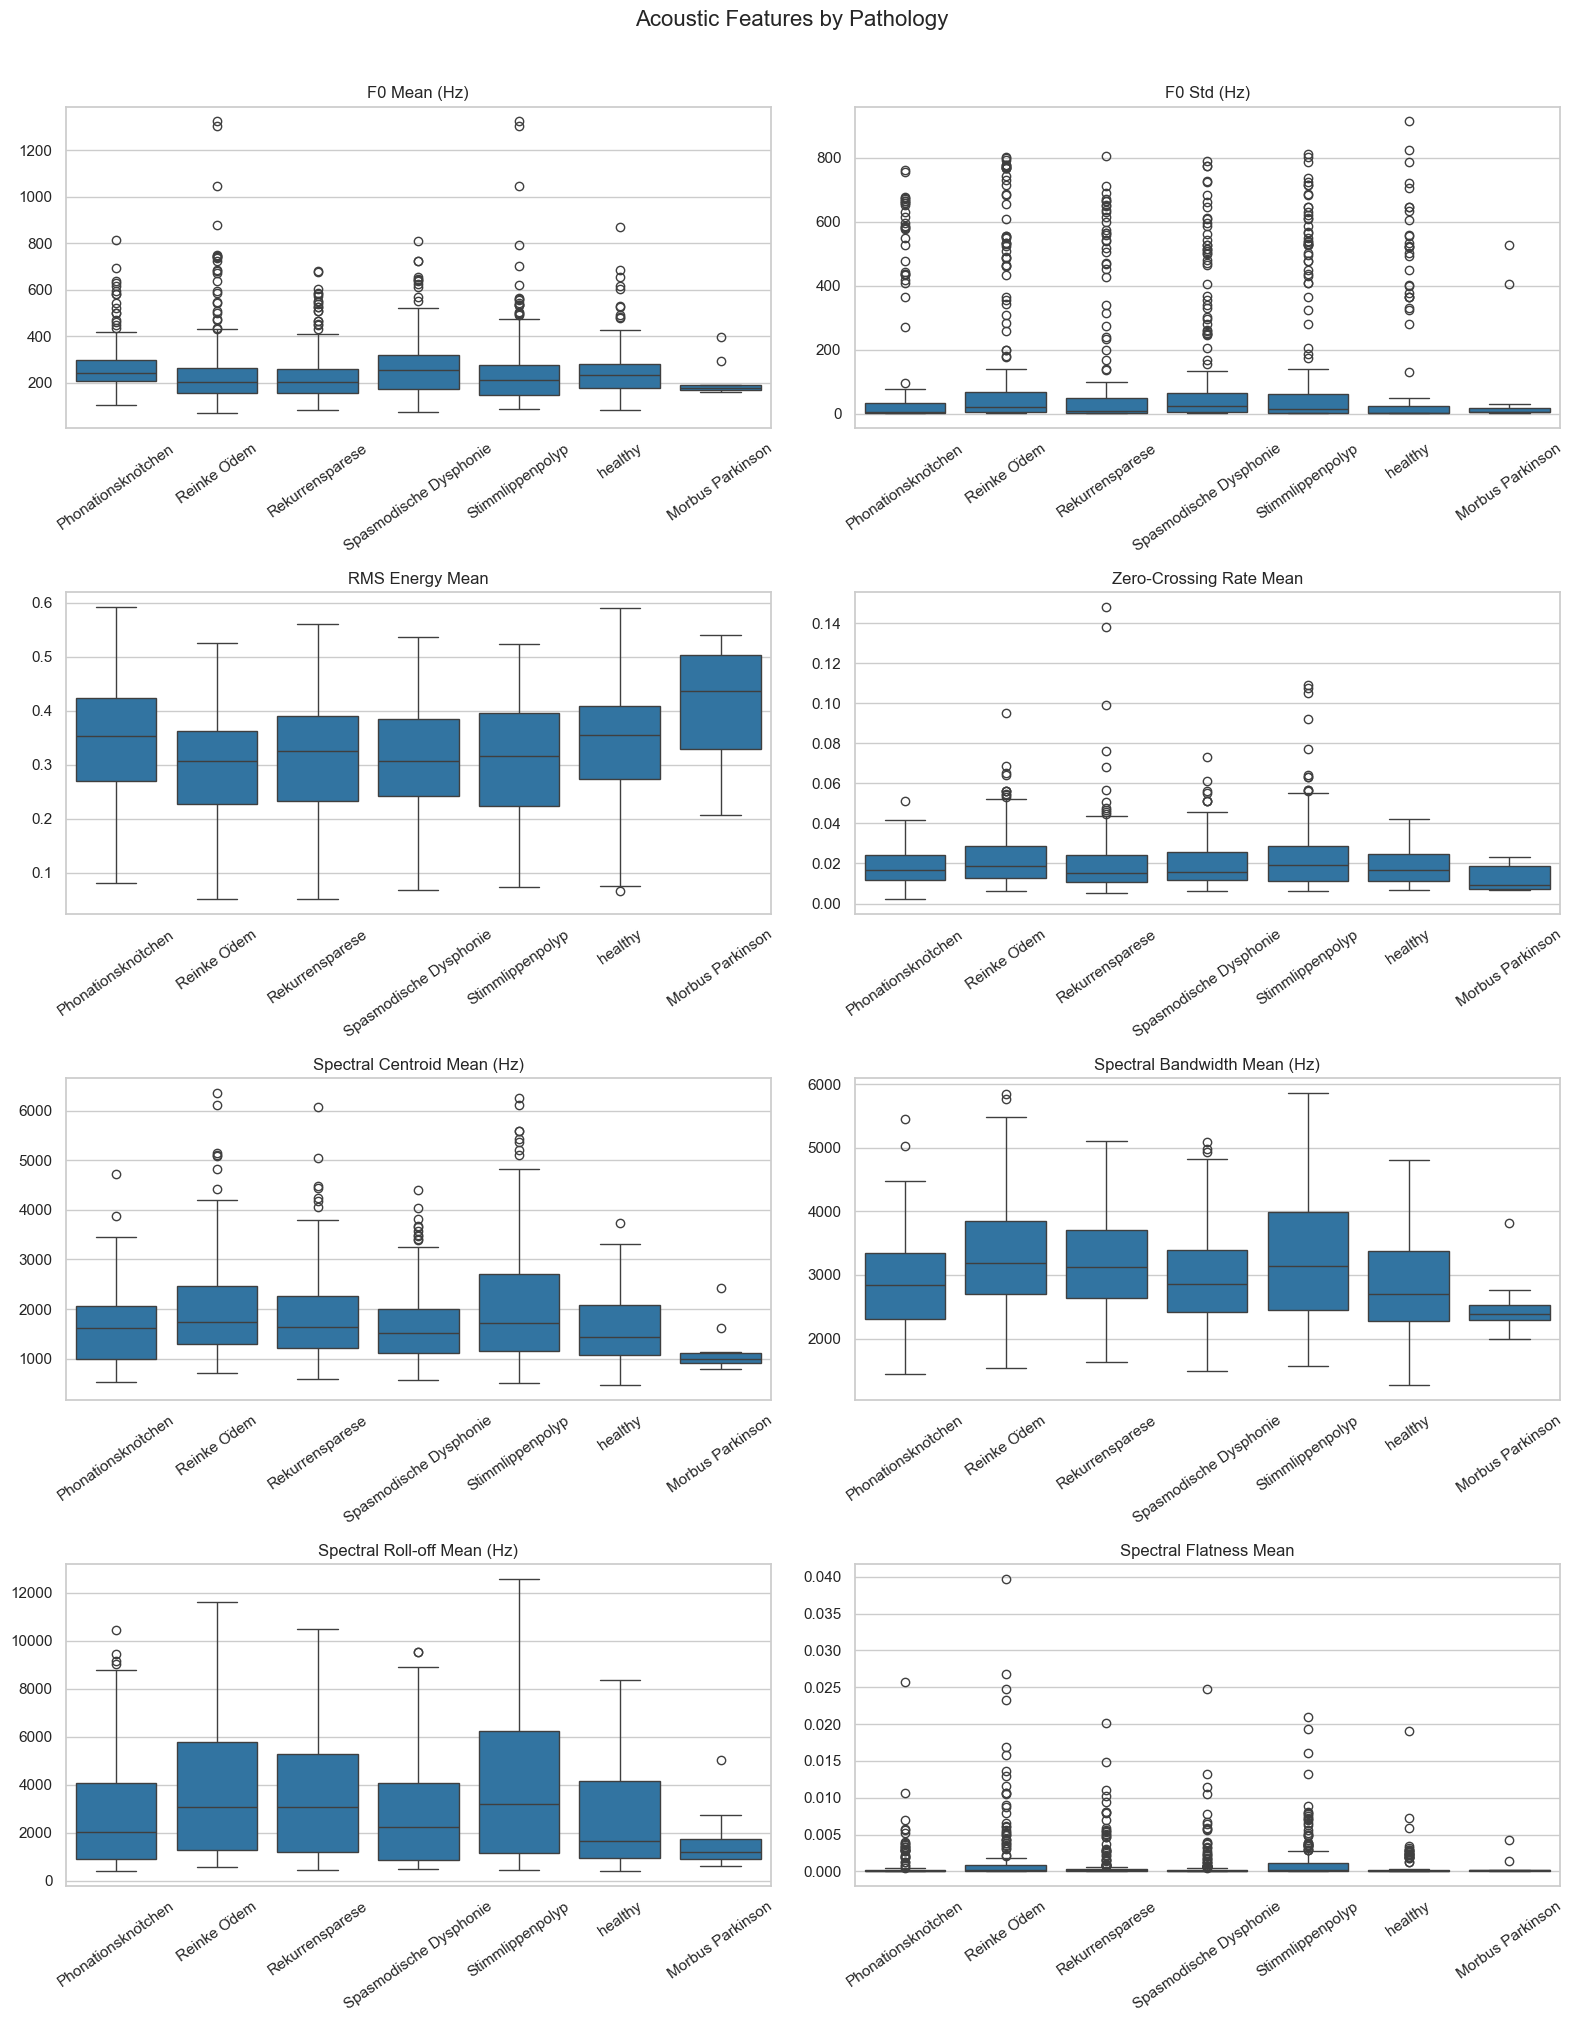

In [6]:
acoustic_cols = {
    'ac_f0_mean':             'F0 Mean (Hz)',
    'ac_f0_std':              'F0 Std (Hz)',
    'ac_rms_mean':            'RMS Energy Mean',
    'ac_zcr_mean':            'Zero-Crossing Rate Mean',
    'ac_spec_centroid_mean':  'Spectral Centroid Mean (Hz)',
    'ac_spec_bandwidth_mean': 'Spectral Bandwidth Mean (Hz)',
    'ac_spec_rolloff_mean':   'Spectral Roll-off Mean (Hz)',
    'ac_spec_flatness_mean':  'Spectral Flatness Mean',
}

present = {k: v for k, v in acoustic_cols.items() if k in df.columns}

ncols = 2
nrows = (len(present) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes_flat = axes.flatten()

for idx, (col, title) in enumerate(present.items()):
    ax = axes_flat[idx]
    sns.boxplot(
        data=df, x='pathology_de', y=col, order=order, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=35)

for ax in axes_flat[len(present):]:
    ax.axis('off')

plt.suptitle('Acoustic Features by Pathology', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

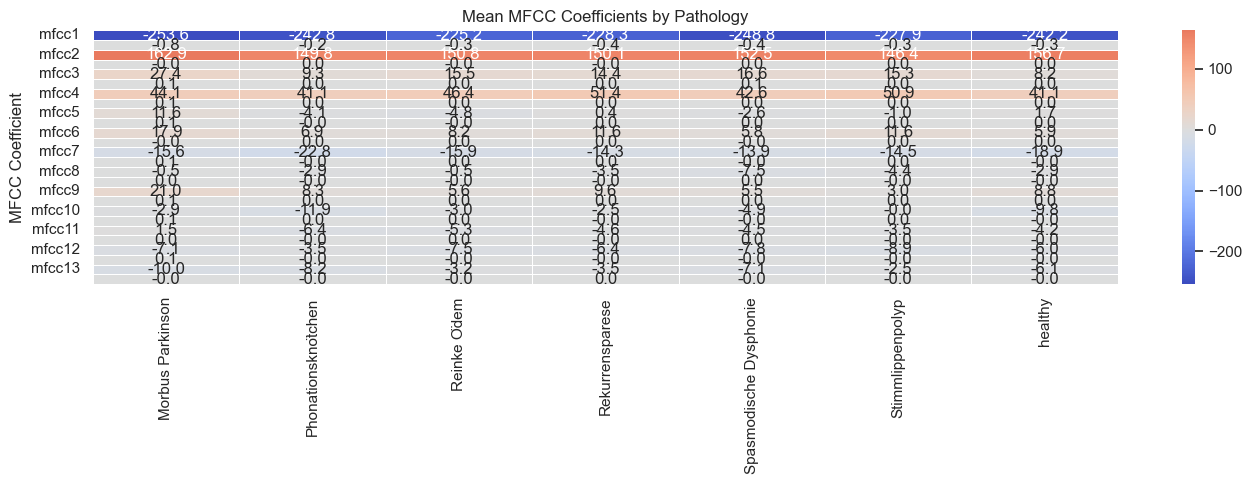

In [7]:
# Mean MFCC coefficients by pathology class
mfcc_cols = [c for c in df.columns if c.startswith('ac_mfcc') and c.endswith('_mean')]

if mfcc_cols:
    mfcc_df = df[['pathology_de'] + mfcc_cols].copy()
    mfcc_means = mfcc_df.groupby('pathology_de')[mfcc_cols].mean()
    mfcc_means.columns = [c.replace('ac_', '').replace('_mean', '') for c in mfcc_means.columns]

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(
        mfcc_means.T,
        cmap='coolwarm',
        center=0,
        annot=True,
        fmt='.1f',
        ax=ax,
        linewidths=0.4,
    )
    ax.set_title('Mean MFCC Coefficients by Pathology')
    ax.set_xlabel('')
    ax.set_ylabel('MFCC Coefficient')
    plt.tight_layout()
    plt.show()

---
## 4  Multifractal Features (MFDFA)

Distributions of the generalised Hurst exponent h(q), the mass scaling function τ(q), the singularity spectrum width, and asymmetry.

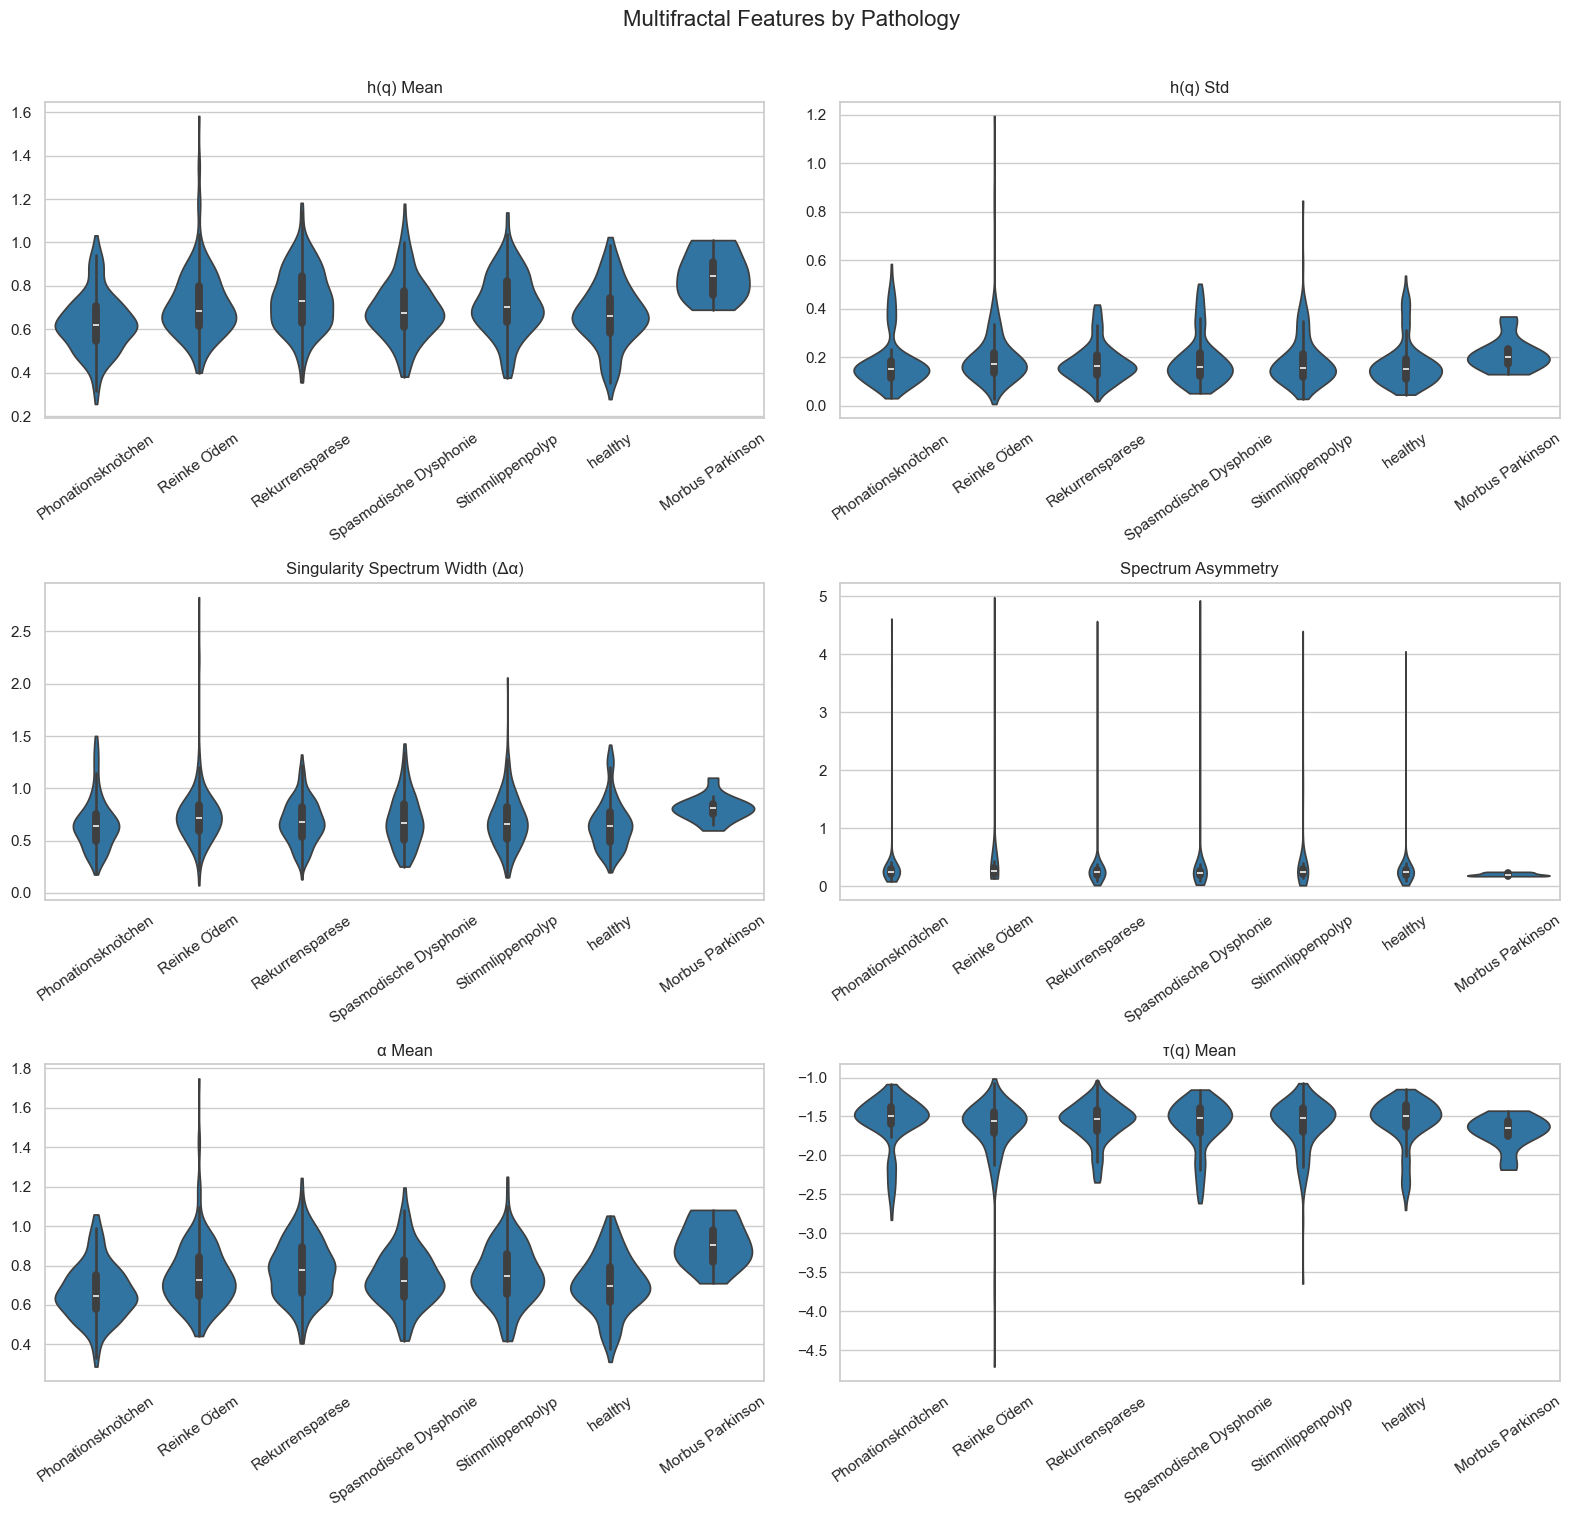

In [8]:
mf_cols = {
    'mf_hq_mean':           'h(q) Mean',
    'mf_hq_std':            'h(q) Std',
    'mf_spectrum_width':    'Singularity Spectrum Width (Δα)',
    'mf_spectrum_asymmetry':'Spectrum Asymmetry',
    'mf_alpha_mean':        'α Mean',
    'mf_tau_mean':          'τ(q) Mean',
}

present_mf = {k: v for k, v in mf_cols.items() if k in df.columns}

ncols = 2
nrows = (len(present_mf) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes_flat = axes.flatten()

for idx, (col, title) in enumerate(present_mf.items()):
    ax = axes_flat[idx]
    sns.violinplot(
        data=df, x='pathology_de', y=col, order=order,
        inner='box', ax=ax, cut=0
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=35)

for ax in axes_flat[len(present_mf):]:
    ax.axis('off')

plt.suptitle('Multifractal Features by Pathology', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---
## 5  OpenSMILE Features (eGeMAPSv02)

Top differentiating eGeMAPS features and a correlation heatmap among eGeMAPS features.

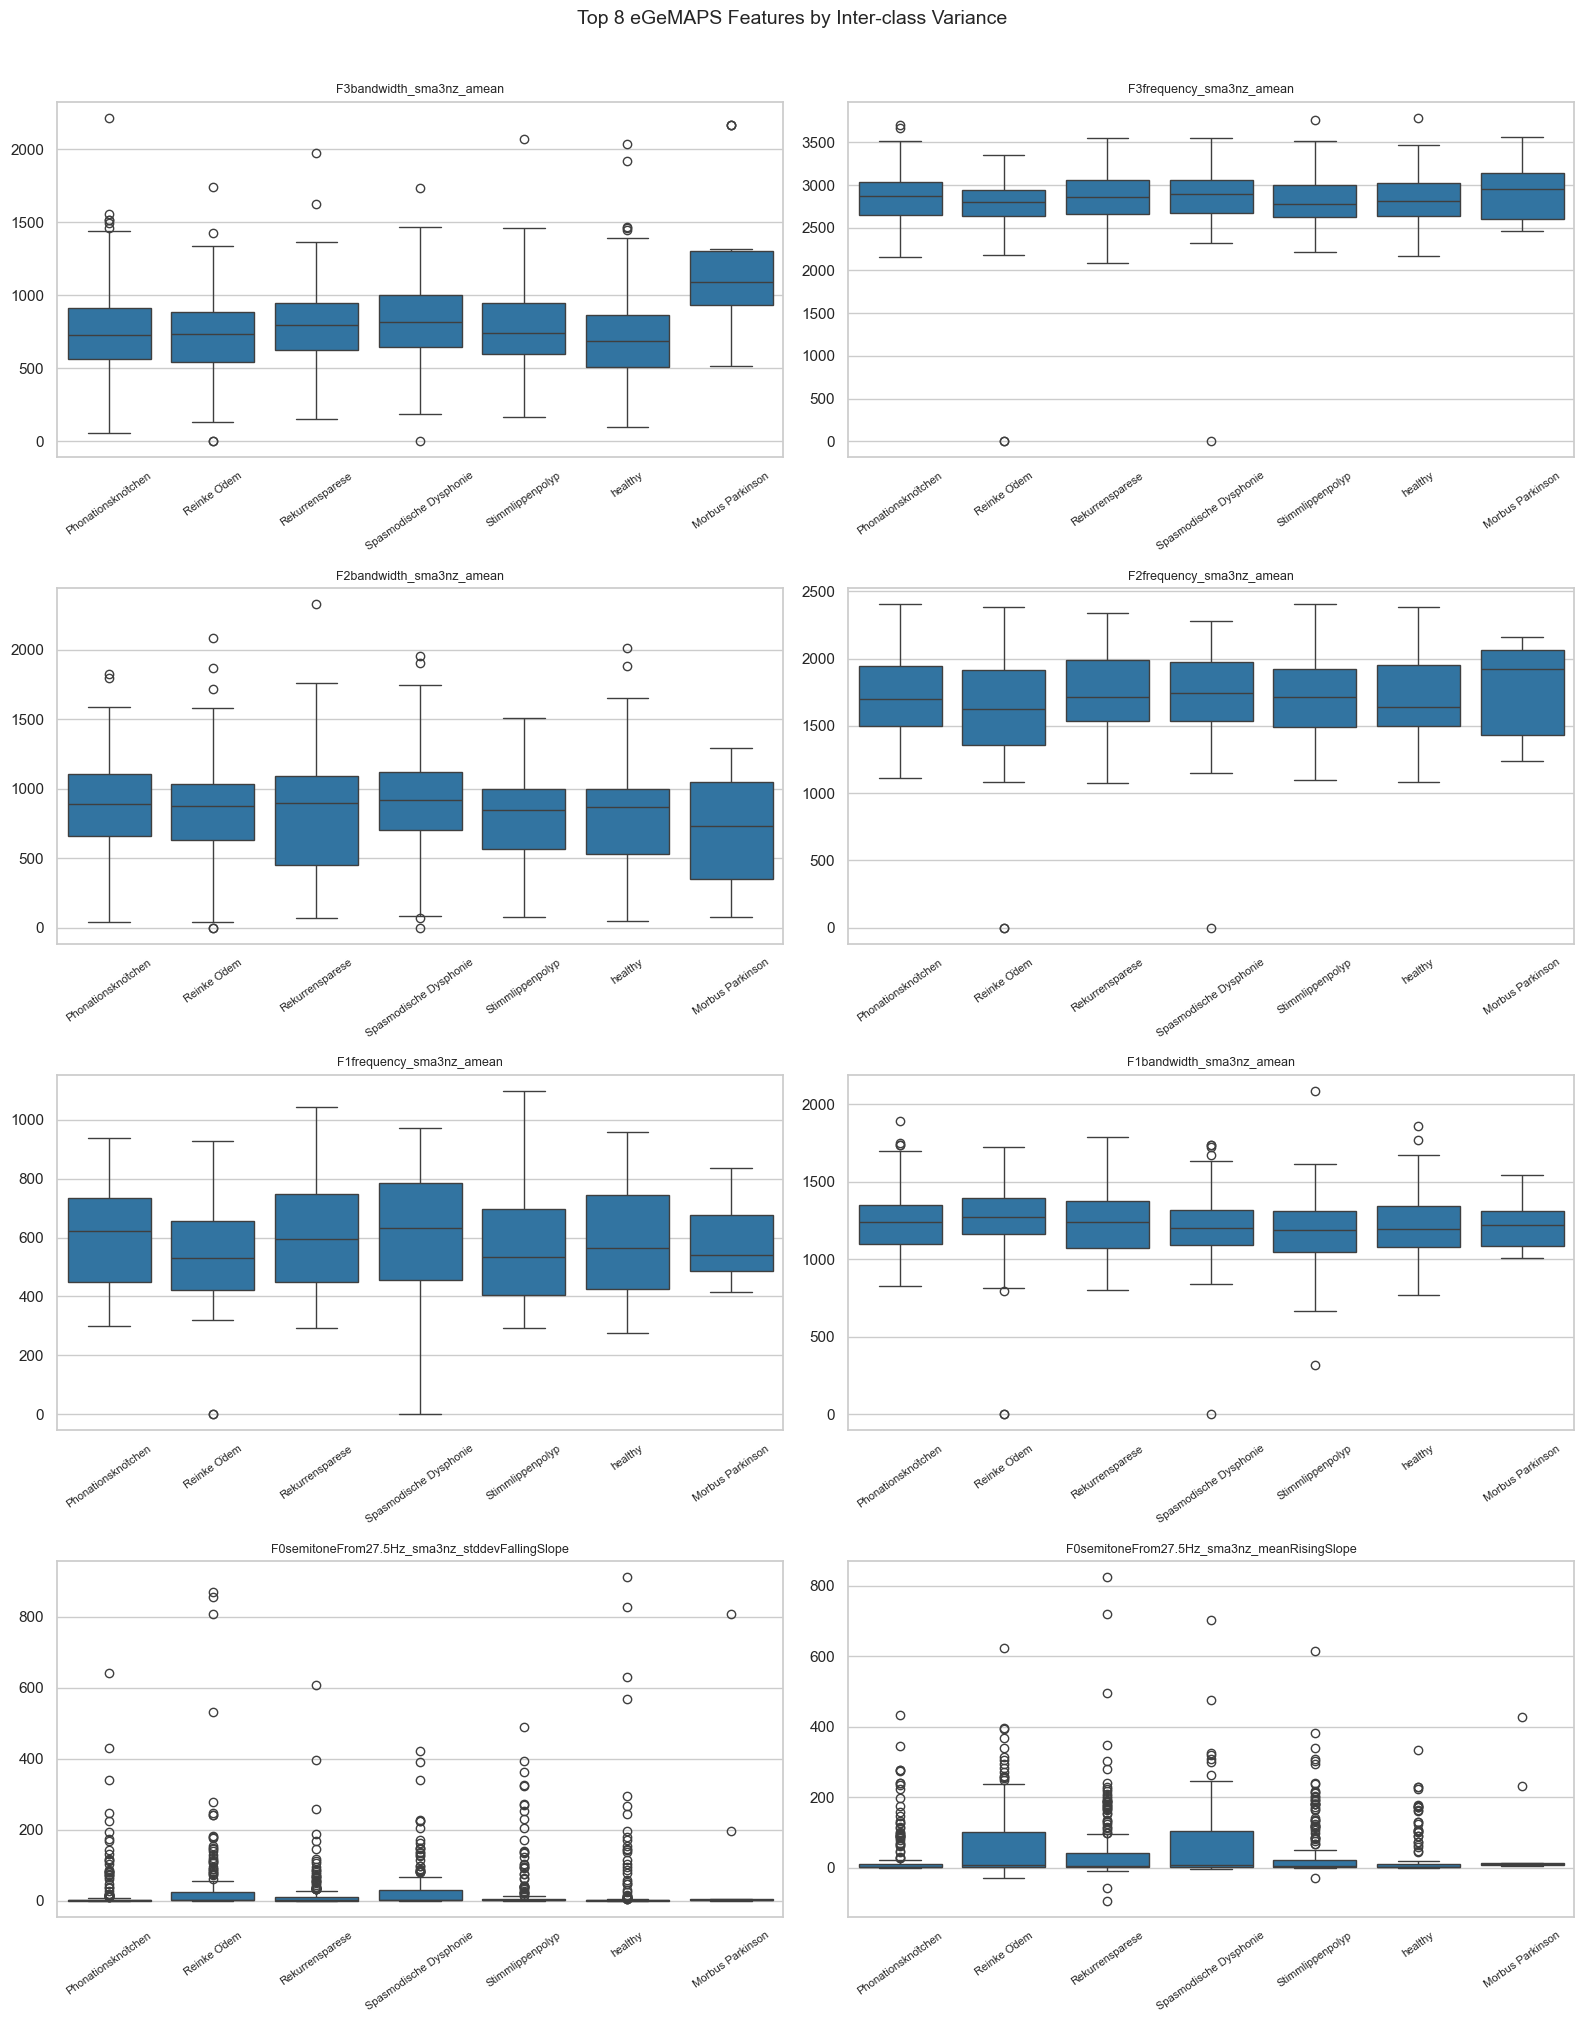

In [9]:
os_cols = [c for c in df.columns if c.startswith('os_')]

if not os_cols:
    print('OpenSMILE features not available in this dataset (run feature extraction with opensmile installed).')
else:
    # Pick top 8 by inter-class variance across pathologies
    class_means = df.groupby('pathology_de')[os_cols].mean()
    inter_var = class_means.var(axis=0).sort_values(ascending=False)
    top_os = inter_var.head(8).index.tolist()

    fig, axes = plt.subplots(4, 2, figsize=(16, 20))
    axes_flat = axes.flatten()

    for idx, col in enumerate(top_os):
        ax = axes_flat[idx]
        short = col.replace('os_', '')
        sns.boxplot(data=df, x='pathology_de', y=col, order=order, ax=ax)
        ax.set_title(short, fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', rotation=35, labelsize=8)

    plt.suptitle('Top 8 eGeMAPS Features by Inter-class Variance', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

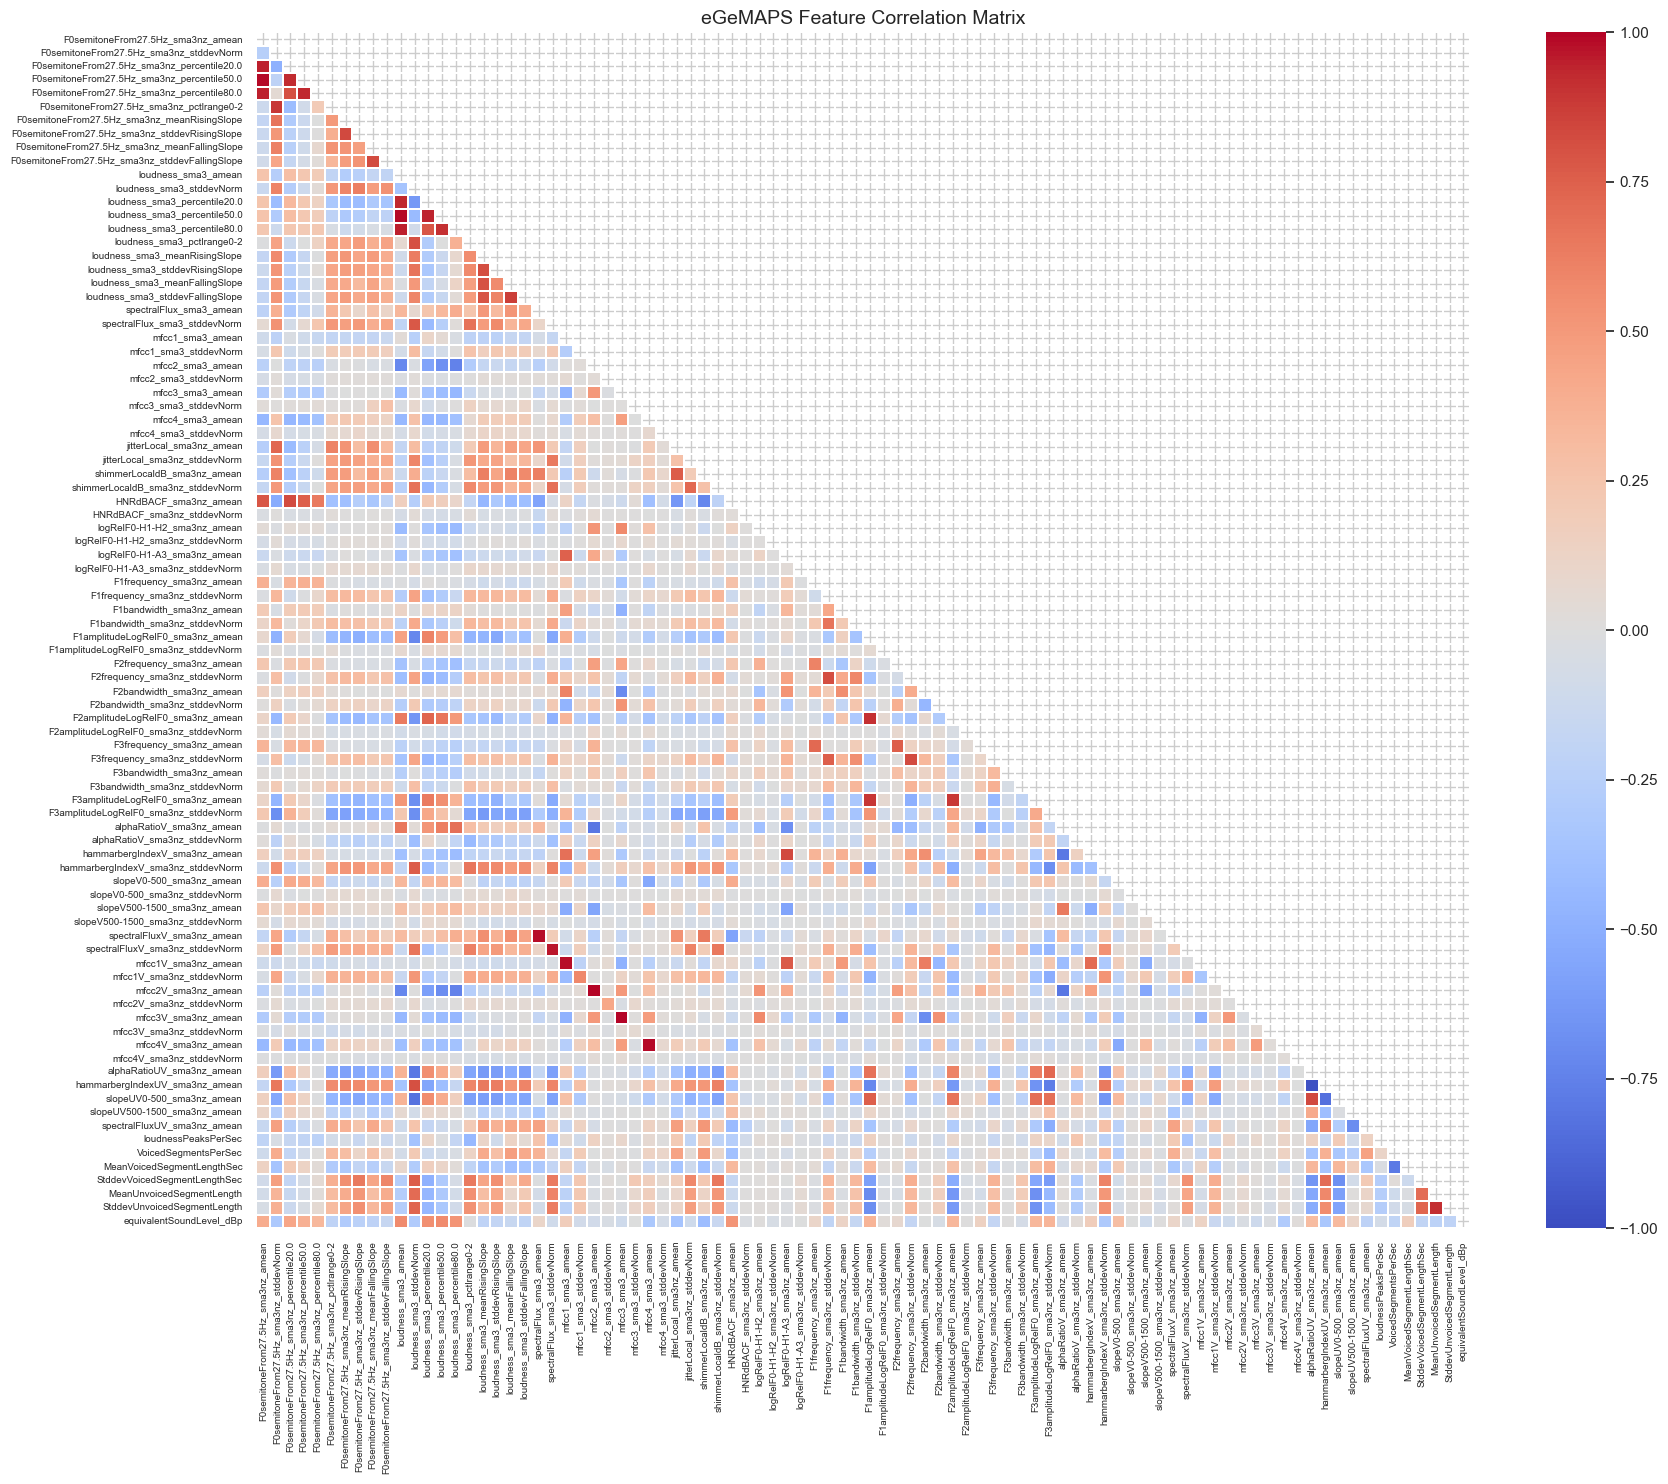

In [10]:
if os_cols:
    corr = df[os_cols].drop(columns=['os_' + c for c in [''] if 'os_' + c in df.columns], errors='ignore').corr()

    fig, ax = plt.subplots(figsize=(18, 15))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, cmap='coolwarm', center=0,
        vmin=-1, vmax=1, linewidths=0.1,
        xticklabels=[c.replace('os_', '') for c in corr.columns],
        yticklabels=[c.replace('os_', '') for c in corr.index],
        ax=ax
    )
    ax.set_title('eGeMAPS Feature Correlation Matrix', fontsize=14)
    ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()

---
## 6  Feature Space — PCA & t-SNE

Dimensionality reduction of the full feature vector, coloured by pathology class.

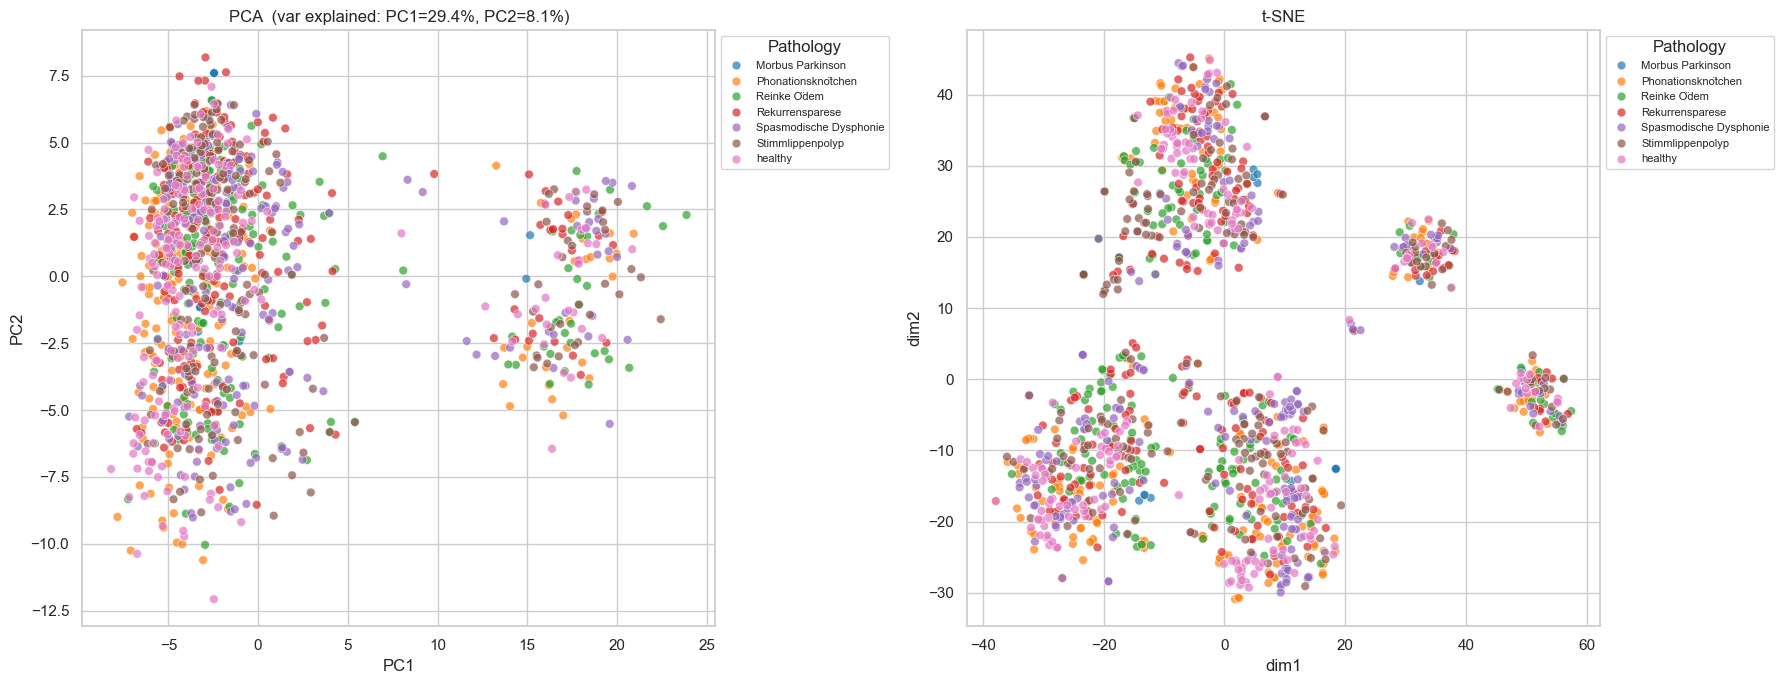

In [12]:
exclude = {
    'sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id',
    'wav_path', 'feature_status', 'feature_error', 'acoustic_status',
    'acoustic_error', 'mf_status', 'mf_error', 'opensmile_status',
    'opensmile_error', 'split', 'split_seed', 'pathology_de', 'pathology_en',
}

feat_cols = [
    c for c in df.columns
    if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
]

X_raw = df[feat_cols].values
labels = df['pathology_de'].values

# Impute + scale
X_imp = SimpleImputer(strategy='median').fit_transform(X_raw)
X_sc  = StandardScaler().fit_transform(X_imp)

# PCA
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X_sc)

# t-SNE (run on PCA-reduced data for speed)
# n_iter was renamed to max_iter in scikit-learn 1.5
X_pca50 = PCA(n_components=min(50, X_sc.shape[1]), random_state=RANDOM_SEED).fit_transform(X_sc)
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)

pca_df  = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'pathology': labels})
tsne_df = pd.DataFrame({'dim1': X_tsne[:, 0], 'dim2': X_tsne[:, 1], 'pathology': labels})

palette = sns.color_palette('tab10', n_colors=len(np.unique(labels)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='pathology',
    palette=palette, alpha=0.7, s=40, ax=axes[0]
)
axes[0].set_title(
    f'PCA  (var explained: PC1={pca.explained_variance_ratio_[0]:.1%}, '
    f'PC2={pca.explained_variance_ratio_[1]:.1%})'
)
axes[0].legend(title='Pathology', bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=8)

sns.scatterplot(
    data=tsne_df, x='dim1', y='dim2', hue='pathology',
    palette=palette, alpha=0.7, s=40, ax=axes[1]
)
axes[1].set_title('t-SNE')
axes[1].legend(title='Pathology', bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

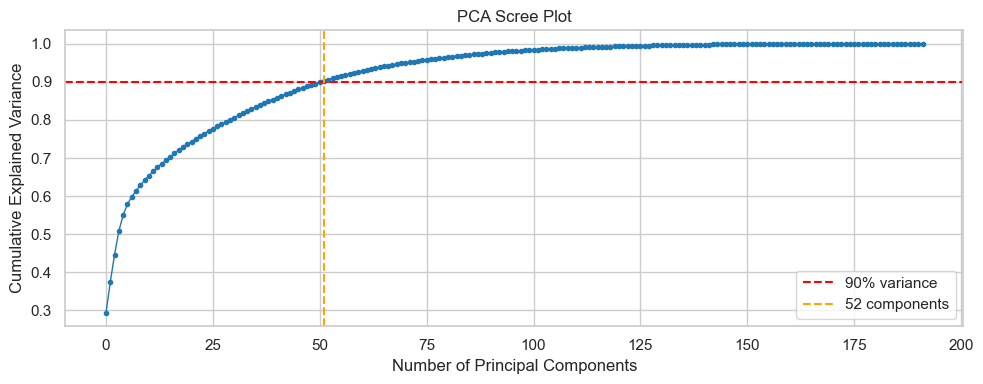

52 principal components explain 90% of the variance (out of 192 features).


In [13]:
# Scree plot — how many PCs capture 90% variance?
pca_full = PCA(random_state=RANDOM_SEED).fit(X_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cumvar, 0.90)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cumvar, marker='.', linewidth=1)
ax.axhline(0.90, color='red', linestyle='--', label='90% variance')
ax.axvline(n90 - 1, color='orange', linestyle='--', label=f'{n90} components')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Scree Plot')
ax.legend()
plt.tight_layout()
plt.show()

print(f'{n90} principal components explain 90% of the variance (out of {X_sc.shape[1]} features).')